# 02_蒙特卡洛模拟（单介质）

本 notebook 实现：给定体积分数 f，随机布置圆柱（微构体中的导电相），并通过截断 + 并查集判断左右电极是否连通，统计导通概率 p(f)。

说明：本 notebook 假定 repo 根目录已包含 src/geometry.py、src/truncation.py、src/connectivity.py 中的必要函数。若运行在本地，请确保 Python path 包含项目根目录。

## 1.Imports 与参数设定 cell

In [1]:
# imports & setup
import os, sys
import numpy as np
import pandas as pd
import time
from multiprocessing import Pool
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
# %matplotlib inline   # 在 notebook 中启用（去掉注释）

# 确保 repo 根在 sys.path（与 notebooks/01 一致的处理）
repo_root = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if repo_root not in sys.path:
    sys.path.append(repo_root)

from src.geometry import Cylinder
from src.truncation import split_cylinder_by_box
from src.connectivity import build_connectivity

# ---------- 参数（可修改） ----------
L = 10000.0  # nm, box edge length
r = 30.0    # nm, cylinder radius
h = 5000.0  # nm, cylinder length
thresh = 1.8  # nm, surface-to-surface 连接阈值

# Monte Carlo 参数
f_grid = np.linspace(0.001, 0.02, 20)  # 体积分数网格（示例：0.1% ~ 2.0%）
trials_per_f = 500  # 每个 f 的独立试验次数（可调）
processes = 4  # 并行进程数（根据机器调整）。在 notebook 中多进程可能需改为 1 或运行为脚本。
seed_base = 20260812

# 输出路径
#修改输出保存路径，应该是根目录下的results文件夹  而不是notebooks文件夹下的results
out_dir = os.path.join(repo_root, 'results', 'outputs')
os.makedirs(out_dir, exist_ok=True)
out_csv = os.path.join(out_dir, 'mc_single_medium.csv')
# ----------------------------------

## 2.工具函数（体积、N 计算、随机生成圆柱）

In [2]:
def volume_cylinder(r, h):
    return np.pi * (r ** 2) * h

def compute_N_from_f(f, L, r, h):
    V_box = L ** 3
    V_cyl = volume_cylinder(r, h)
    if V_cyl <= 0:
        raise ValueError('Cylinder volume must be positive')
    N = int(round((f * V_box) / V_cyl))
    return max(0, N)

def sample_random_cylinders(N, L, r, h, seed=None):
    rng = np.random.default_rng(seed)
    centers = rng.uniform(-L/2, L/2, size=(N, 3))
    # 方向使用正态分布再归一化（球面均匀）
    dirs = rng.normal(size=(N, 3))
    norms = np.linalg.norm(dirs, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    dirs = dirs / norms
    half = (h / 2.0)
    cyls = []
    for i in range(N):
        c = centers[i]
        d = dirs[i]
        p0 = c - d * half
        p1 = c + d * half
        cyls.append(Cylinder(p0, p1, r, id=i))
    return cyls

## 3.单次试验 wrapper、Wilson 置信区间

In [3]:
def run_single_trial(args):
    # 用于 Pool.map 的 wrapper，参数打包为 (N, L, r, h, thresh, seed)
    N, L, r, h, thresh, seed = args
    cyls = sample_random_cylinders(N, L, r, h, seed=seed)
    segments = []
    for c in cyls:
        segs = split_cylinder_by_box(c, L)
        segments.extend(segs)
    connected, _uf = build_connectivity(segments, L, thresh)
    return 1 if connected else 0

def wilson_interval(k, n, z=1.96):
    # k successes in n trials, returns (low, high) for proportion
    if n == 0:
        return (0.0, 0.0)
    phat = k / n
    denom = 1 + (z**2)/n
    centre = phat + (z**2)/(2*n)
    adj = z * np.sqrt((phat*(1-phat) + (z**2)/(4*n)) / n)
    low = (centre - adj) / denom
    high = (centre + adj) / denom
    return max(0.0, low), min(1.0, high)

## 4.对单个 f 运行 Monte Carlo 的函数

In [4]:
def run_monte_carlo_for_f(f, trials, L, r, h, thresh, seed_base=0, processes=1):
    N = compute_N_from_f(f, L, r, h)
    if trials <= 0:
        return {'f': f, 'N': N, 'trials': trials, 'successes': 0, 'p_hat': 0.0, 'ci_low': 0.0, 'ci_high': 0.0}
    args_list = []
    for t in range(trials):
        seed = int(seed_base + t + int(f*1e9) % 1000000)
        args_list.append((N, L, r, h, thresh, seed))
    start = time.time()
    if processes == 1:
        results = [run_single_trial(a) for a in args_list]
    else:
        # NOTE: 在 Jupyter 中直接使用 multiprocessing.Pool 可能会遇到问题（尤其 Windows）。
        # 若要在 notebook 中并行，建议把此文件保存为脚本并以 python 运行，或在 notebook 中把 processes=1。
        with Pool(processes) as pool:
            results = pool.map(run_single_trial, args_list)
    successes = int(sum(results))
    p_hat = successes / trials
    ci_low, ci_high = wilson_interval(successes, trials)
    elapsed = time.time() - start
    return {'f': f, 'N': N, 'trials': trials, 'successes': successes, 'p_hat': p_hat, 'ci_low': ci_low, 'ci_high': ci_high, 'elapsed_s': elapsed}

## 5. 主循环：扫描 f_grid、保存结果

In [ ]:
# 扫描 f_grid（可能耗时较长）
results = []
total_start = time.time()
for f in f_grid:
    print(f'Running f={f:.6f} -> N estimation ...')
    res = run_monte_carlo_for_f(f, trials_per_f, L, r, h, thresh, seed_base=seed_base, processes=processes)
    print(f"  f={f:.6f}, N={res['N']}, successes={res['successes']}/{res['trials']}, p_hat={res['p_hat']:.4f}, time={res['elapsed_s']:.1f}s")
    results.append(res)
total_elapsed = time.time() - total_start
print(f'All done, total time: {total_elapsed:.1f}s')

# 保存结果为 CSV
df_res = pd.DataFrame(results)
df_res.to_csv(out_csv, index=False)
print('Saved results to', out_csv)

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import os

repo_root = os.path.dirname(os.getcwd())
csv_path = os.path.join(repo_root, 'results/outputs/monte_carlo_results.csv')

df = pd.read_csv(csv_path)
df.head(20)

,f,N,trials,successes,p_hat,ci_low,ci_high,elapsed_s
0,0.001,71,500,500,1.0,0.992375,1.0,0.928175
1,0.002,141,500,500,1.0,0.992375,1.0,1.155437
2,0.003,212,500,500,1.0,0.992375,1.0,1.713052
3,0.004,283,500,500,1.0,0.992375,1.0,2.233311
4,0.005,354,500,500,1.0,0.992375,1.0,2.774658
5,0.006,424,500,500,1.0,0.992375,1.0,3.563938
6,0.007,495,500,500,1.0,0.992375,1.0,4.863136
7,0.008,566,500,500,1.0,0.992375,1.0,5.396955
8,0.009,637,500,500,1.0,0.992375,1.0,6.396657
9,0.010,707,500,500,1.0,0.992375,1.0,7.778270


## 6. 绘图

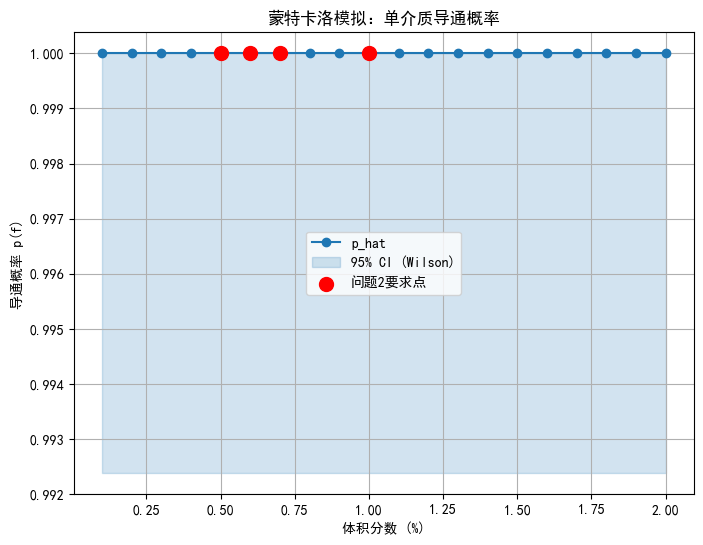

In [15]:
import matplotlib.pyplot as plt

# 绘图：p(f) 与 95% CI
plt.figure(figsize=(8,6))

# 直接用 df 里的数据
plt.plot(df['f']*100, df['p_hat'], '-o', label='p_hat')
plt.fill_between(df['f']*100, df['ci_low'], df['ci_high'], color='C0', alpha=0.2, label='95% CI (Wilson)')

# 标出问题2要求的4个点
target_f = [0.005, 0.006, 0.007, 0.010]  # 0.5%, 0.6%, 0.7%, 1.0%
target_df = df[df['f'].isin(target_f)]
plt.scatter(target_df['f']*100, target_df['p_hat'], color='red', s=100, zorder=5, label='问题2要求点')

plt.xlabel('体积分数 (%)')
plt.ylabel('导通概率 p(f)')
plt.title('蒙特卡洛模拟：单介质导通概率')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# 绘图：p(f) 与 95% CI
if len(results) > 0:
    fs = [r['f'] for r in results]
    p_hats = [r['p_hat'] for r in results]
    lows = [r['ci_low'] for r in results]
    highs = [r['ci_high'] for r in results]
    plt.figure(figsize=(8,6))
    plt.plot(fs, p_hats, '-o', label='p_hat')
    plt.fill_between(fs, lows, highs, color='C0', alpha=0.2, label='95% CI (Wilson)')
    plt.xlabel('体积分数 f')
    plt.ylabel('导通概率 p(f)')
    plt.title('蒙特卡洛模拟：单介质导通概率')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print('No results to plot')

NameError: name 'results' is not defined

---
说明与下一步建议：
- 这是一个可运行的初始版本，重心在功能完整性而非极致性能优化。
- 对于生产级别的扫描，建议：使用更大的 trials（尤其在 p≈0.5 附近）、在 run_single_trial 中优化几何判断（KD-tree、Numba）、以及在进程级别避免频繁序列化大型对象。
- 我可以把该 notebook 提交到仓库（如果你需要我继续尝试提交请告知），或者把上面代码整理成脚本版本（scripts/run_monte_carlo.py），便于命令行并行执行（推荐用于大规模试验）。